# Spatial null models

If you correlate two brain maps and read off the p-value, you will overstate your evidence — often
by a lot. This tutorial explains why, shows what the geometry of the brain has to do with it, and 
demonstrates what {mod}`snaplab_tools.nulls` does about it.

In human neuroscience, we often use a range of *null models* to draw inferences from data. These
nulls take many forms but are all fundamentally based on the idea of randomly shuffling (i.e.,
permuting) your data and then re-assessing your effect or parameter of interest using the permuted
data.

For example, imagine you are interested in the correlation between variables `X` and `Y`. Let's
say that when both `X` and `Y` are in their original unshuffled state (i.e., `X_true`, `Y_true`),
they yield some correlation coefficient, `corr(X_true, Y_true) = 0.50`. You can use a permutation
test to see if that effect is *significantly larger than would occur by chance*.

You would do this by randomly shuffling one, *and only one*, of these variables thousands of
times. Let's say you choose to randomly shuffle `X` 5,000 times. For each randomly shuffled
version of `X`, `X_shuf`, you would recompute your correlation, `corr(X_shuf, Y_true) = 0.20`.
Once you've done that, say, 5,000 times for each instance of `X_shuf`, you will have a *null
distribution containing 5,000 correlation coefficients*. By chance alone, some of the values in
your null will yield substantially non-zero correlations. Then, the question becomes: **how many
times do you observe correlations in your null that exceed the size of your true correlation?**
The empirical answer to this question becomes your p-value.

While conceptually straightforward, the above example *does not work in human neuroimaging*. This
is because the data we use in our field has complex properties that mean we cannot just naively
shuffle the data and recompute outputs. MRI data is characterized by smooth spatial variations: a
region with a certain cortical thickness will have neighbouring regions that all have very similar
levels of cortical thickness. This **autocorrelated** nature of our data means we cannot just
randomly swap cortical thickness values around and recompute correlations to some other brain
metric. Instead, we need nulls that *preserve* these complex features when shuffling values.

For a detailed discussion, see [Váša & Mišić, 2022, *Nature Reviews
Neuroscience*](https://www.nature.com/articles/s41583-022-00601-9).

# 1) Spatial autocorrelation-preserving null

The first null we will consider links directly to the above example. This null model generates a
permuted version of a brain map while preserving the spatial autocorrelation (SA) of that brain
map. There are many implementations of such an SA-preserving null, but we favour one called
BrainSMASH. See [Burt et al., 2020, *NeuroImage*](https://doi.org/10.1016/j.neuroimage.2020.117038)
and the authors' [readthedocs](https://brainsmash.readthedocs.io/en/latest/) page for more detail.

:::{admonition} Please cite
:class: seealso

Burt, J.B., Helmer, M., Shinn, M., Anticevic, A., & Murray, J.D. (2020). Generative modeling of
brain maps with spatial autocorrelation. *NeuroImage*, 220, 117038.
<https://doi.org/10.1016/j.neuroimage.2020.117038>
:::

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as st
import seaborn as sns

from snaplab_tools.datasets import make_spatial_map, make_correlated_map
from snaplab_tools.nulls import (
    load_distance_matrix,   # bundled Euclidean / geodesic parcel distance matrices
    generate_surrogates,    # per-hemisphere BrainSMASH surrogates (NaN-safe)
    corr_with_null,         # one-call spatial correlation + BrainSMASH p-value
    corr_with_covar_null,
    correlate_family,
)
from snaplab_tools.stats import get_null_p
from snaplab_tools.plotting.plotting import plot_correlation, null_plot
from snaplab_tools.plotting.utils import set_plotting_params

set_plotting_params()

## Load data

We need a pair of vectors that encode some brain data. In a real analysis these would be
measurements: a map of intracortical myelin content extracted from the T1w/T2w ratio, say, and a
map of intrinsic neural timescales extracted by quantifying the decay of an autocorrelation
function fit to regional resting-state fMRI time series. You would correlate those two maps and
use BrainSMASH to compute the p-value.

So that this notebook runs anywhere, here we will instead use synthetic stand-ins from
{mod}`snaplab_tools.datasets`. They are not arbitrary: they are generated over the *real*
Schaefer-400 geometry bundled with the package, so they carry genuine spatial autocorrelation —
which is the property the rest of this tutorial is about. Substitute your own maps and
every cell below works unchanged.

In [2]:
# Stand-ins for two parcellated measurements, planted with a moderate negative correlation.
myelin = make_spatial_map(n_regions=400, seed=0)
timescale = make_correlated_map(myelin, rho=-0.35, seed=1)

print(myelin.shape, timescale.shape)

(400,) (400,)


## Plot our true correlation

Now let's plot a basic correlation using these synthetic data.

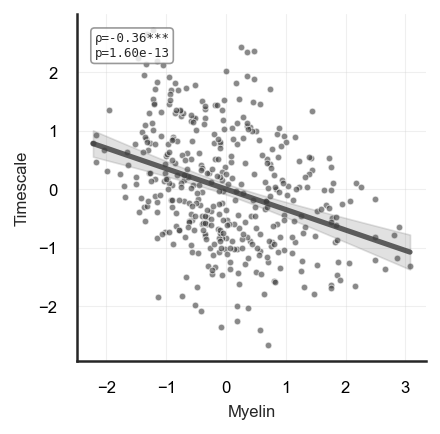

In [3]:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(3, 3), dpi=150)
plot_correlation(myelin, timescale, axes,
                 x_label='Myelin', y_label='Timescale',
                 method='spearman')
plt.show()

## The distance matrix is the key ingredient

BrainSMASH works by matching the **variogram** of your map: how much the map varies between pairs
of regions, *as a function of the distance between them*. So the distance matrix you feed it
defines what "spatial autocorrelation" even means. Get the distance wrong and every surrogate —
and therefore your p-value — is built on the wrong geometry.

The naive choice is the **Euclidean** distance between region centroids: the straight-line
distance through the brain. But the cortex is a crumpled sheet. Two regions on opposite banks of a
sulcus are a few millimetres apart in a straight line, yet to travel between them *along the
cortical surface* you have to go all the way down one bank and up the other. The metric that
respects the sheet is **geodesic** distance — distance measured along the surface — and it is the
basis the BrainSMASH authors recommend for surface parcellations (Burt et al., 2020).

{mod}`snaplab_tools.nulls` bundles both, precomputed for the Schaefer-400 (7-network, fsLR)
parcellation, so we can load and compare them directly — no parcellation files or manual distance
computation required:

In [4]:
# Both distance bases ship with snaplab_tools (Schaefer-400, 7 networks, fsLR).
D_euclid, hemi = load_distance_matrix(n_regions=400, kind='euclidean')
D_geo,    hemi = load_distance_matrix(n_regions=400, kind='geodesic')

print('Euclidean :', D_euclid.shape, '-> full matrix')
print('Geodesic  :', D_geo.shape, '-> per-hemisphere (cross-hemisphere entries are NaN)')
print('hemispheres:', (hemi == 'L').sum(), 'L /', (hemi == 'R').sum(), 'R')

Euclidean : (400, 400) -> full matrix
Geodesic  : (400, 400) -> per-hemisphere (cross-hemisphere entries are NaN)
hemispheres: 200 L / 200 R


### 1. They look similar globally...

Both matrices capture the coarse structure — nearby regions are close (dark), distant regions are
far (bright). Note the geodesic matrix is **block-diagonal**: geodesic distance is only defined
*within* a hemisphere (the left and right surfaces are separate sheets), so the off-diagonal
left↔right blocks are blank (NaN).

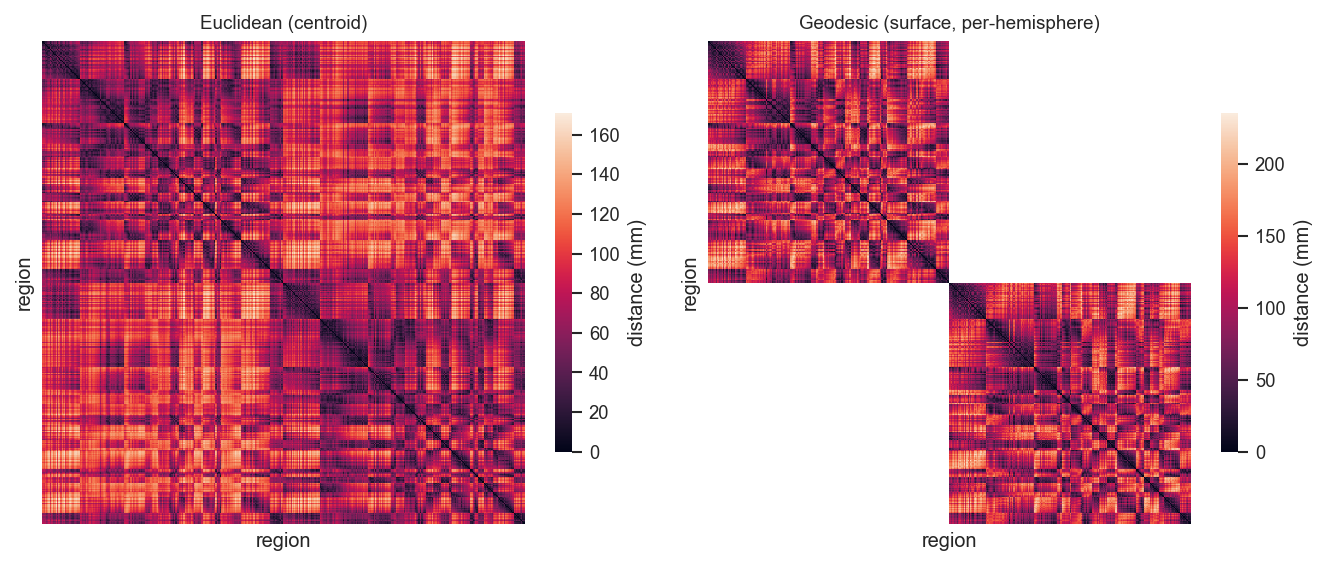

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4), dpi=150)
for ax, D, title in [(axes[0], D_euclid, 'Euclidean (centroid)'),
                     (axes[1], D_geo, 'Geodesic (surface, per-hemisphere)')]:
    sns.heatmap(D, ax=ax, square=True, cmap='rocket',
                cbar_kws={'label': 'distance (mm)', 'shrink': .6})
    ax.set_title(title, fontsize=9)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_xlabel('region'); ax.set_ylabel('region')
plt.tight_layout(); plt.show()

### 2. ...but Euclidean systematically *underestimates* cortical distance

Plot the two distances against each other, for every within-hemisphere pair of regions. If they
agreed, points would sit on the dashed `y = x` line. Instead almost every point sits **above** it:
the true (geodesic) distance is longer than the straight-line distance, because the straight line
cheats by cutting through the folds.

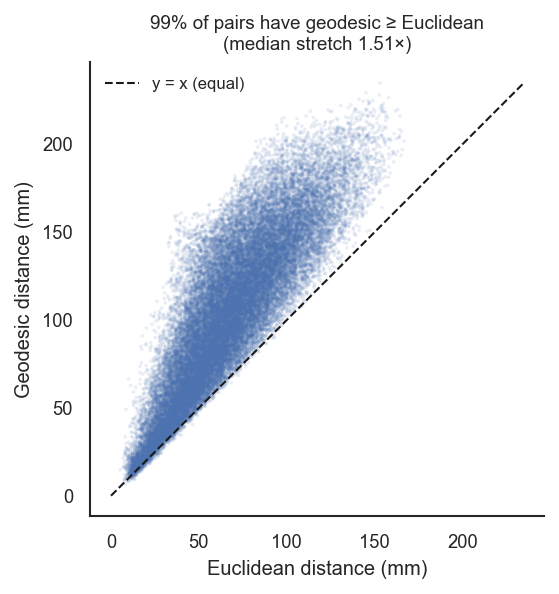

In [6]:
iu = np.triu_indices(400, 1)
within = np.isfinite(D_geo[iu]) & (D_geo[iu] > 0)   # within-hemisphere pairs only
e, g = D_euclid[iu][within], D_geo[iu][within]

fig, ax = plt.subplots(figsize=(4, 4), dpi=150)
ax.scatter(e, g, s=3, alpha=.12, color='#4C72B0', edgecolor='none')
lim = max(e.max(), g.max())
ax.plot([0, lim], [0, lim], 'k--', lw=1, label='y = x (equal)')
ax.set_xlabel('Euclidean distance (mm)'); ax.set_ylabel('Geodesic distance (mm)')
ax.set_title(f'{np.mean(g >= e) * 100:.0f}% of pairs have geodesic ≥ Euclidean\n'
             f'(median stretch {np.median(g / e):.2f}×)', fontsize=9)
ax.legend(fontsize=8, frameon=False); ax.set_aspect('equal'); sns.despine()
plt.tight_layout(); plt.show()

### 3. The intuition: a single fold

Here is the whole story in one cartoon. Two regions **A** and **B** sit on opposite banks of a
sulcus. The straight (Euclidean) line between them is artificially short. The geodesic path stays on the surface, down into
the sulcus and back up, and is far longer. Euclidean distance mistakes B for a close neighbour of
A when it is actually farther away *on the cortex*.

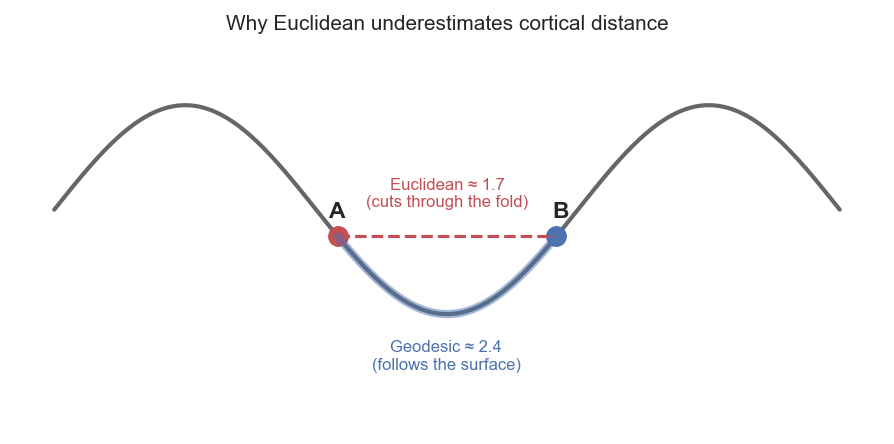

In [7]:
t = np.linspace(0, 2 * np.pi, 400)
x, y = t, np.sin(t * 1.5)                      # a folded cortical-surface profile

fig, ax = plt.subplots(figsize=(6, 3), dpi=150)
ax.plot(x, y, color='0.4', lw=2)

iA = np.argmin(np.abs(t - np.pi * 0.72)); iB = np.argmin(np.abs(t - np.pi * 1.28))
A, B = (x[iA], y[iA]), (x[iB], y[iB])
ax.plot(*A, 'o', color='#C44E52', ms=9); ax.plot(*B, 'o', color='#4C72B0', ms=9)
ax.annotate('A', A, textcoords='offset points', xytext=(-4, 9), fontsize=11, fontweight='bold')
ax.annotate('B', B, textcoords='offset points', xytext=(-2, 9), fontsize=11, fontweight='bold')

ax.plot([A[0], B[0]], [A[1], B[1]], '--', color='#C44E52', lw=1.5)
eu = np.hypot(B[0] - A[0], B[1] - A[1])
# Each label sits beside its own path: the Euclidean note just above the straight dashed line,
# the geodesic note below the curve it describes. Offsetting them the other way puts each label
# closer to the other path, which is how this figure gets misread.
ax.annotate(f'Euclidean ≈ {eu:.1f}\n(cuts through the fold)',
            ((A[0] + B[0]) / 2, (A[1] + B[1]) / 2 + 0.25), color='#C44E52', fontsize=8,
            ha='center', va='bottom')

gx, gy = x[iA:iB + 1], y[iA:iB + 1]
ax.plot(gx, gy, color='#4C72B0', lw=4, alpha=.5)
gl = np.sum(np.hypot(np.diff(gx), np.diff(gy)))
ax.annotate(f'Geodesic ≈ {gl:.1f}\n(follows the surface)',
            (x[(iA + iB) // 2], y[(iA + iB) // 2] - 0.25), color='#4C72B0', fontsize=8,
            ha='center', va='top')

ax.set_ylim(-2.1, 1.6)
ax.set_title('Why Euclidean underestimates cortical distance', fontsize=10)
ax.axis('off'); plt.tight_layout(); plt.show()

### 4. Euclidean even links the two hemispheres

Because Euclidean distance is just straight-line geometry, it reports small distances between
regions on *opposite* hemispheres that sit near the midline — as if they were neighbours. But the
hemispheres are physically separate surfaces, so there is no surface path between them and
geodesic distance is simply undefined. This is exactly why the geodesic matrix is block-diagonal,
and why {func}`~snaplab_tools.nulls.generate_surrogates` builds surrogates **per hemisphere** for
the geodesic basis.

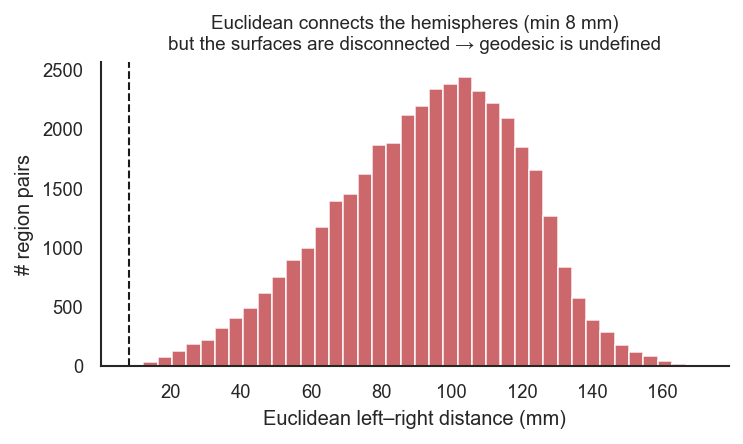

In [8]:
# Cross-hemisphere pairs, taken from the hemisphere labels rather than assumed to be the first
# and last 200 rows.
cross = np.outer(hemi == 'L', hemi == 'R')
ce = D_euclid[cross]

fig, ax = plt.subplots(figsize=(5, 3), dpi=150)
ax.hist(ce, bins=40, color='#C44E52', alpha=.85)
ax.axvline(ce.min(), color='k', ls='--', lw=1)
ax.set_xlabel('Euclidean left–right distance (mm)'); ax.set_ylabel('# region pairs')
ax.set_title(f'Euclidean connects the hemispheres (min {ce.min():.0f} mm)\n'
             f'but the surfaces are disconnected → geodesic is undefined', fontsize=9)
sns.despine(); plt.tight_layout(); plt.show()

### 5. Why this corrupts the null

BrainSMASH bins region pairs by distance to build the variogram. So the damage from a wrong
distance is concrete: **Euclidean lumps together pairs whose true surface separations are wildly
different.** Take every pair that Euclidean calls "~20 mm apart" — geodesically they range from
genuinely adjacent to nearly 100 mm apart. BrainSMASH treats them all as the same lag, smearing
the spatial-autocorrelation structure it is supposed to preserve. The geodesic basis keeps them
separate, so the surrogates — and the p-value — reflect the real geometry of the cortex.

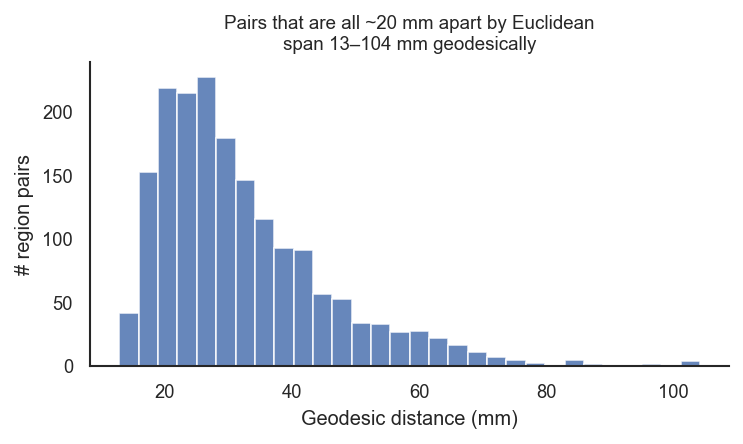

In [9]:
band = (e >= 15) & (e < 25)     # all "~20 mm" apart by Euclidean
fig, ax = plt.subplots(figsize=(5, 3), dpi=150)
ax.hist(g[band], bins=30, color='#4C72B0', alpha=.85)
ax.set_xlabel('Geodesic distance (mm)'); ax.set_ylabel('# region pairs')
ax.set_title(f'Pairs that are all ~20 mm apart by Euclidean\n'
             f'span {g[band].min():.0f}–{g[band].max():.0f} mm geodesically', fontsize=9)
sns.despine(); plt.tight_layout(); plt.show()

## Running BrainSMASH with the geodesic basis

Now the payoff. {func}`~snaplab_tools.nulls.generate_surrogates` wraps BrainSMASH: it takes a map,
handles the per-hemisphere geodesic bookkeeping and NaNs for you, and returns `n_perms` surrogate
maps.

`n_perms=500` keeps this notebook running quickly. But you should use **5,000–10,000 for anything you report** — a null of size
*n* cannot express a p-value below `1/n`, so 500 surrogates bottom out at p = 0.002.

In [10]:
n_perms = 500

# Recommended: geodesic, per-hemisphere (the default for kind='geodesic').
myelin_null_geo = generate_surrogates(myelin, n_regions=400, n_perms=n_perms,
                                      kind='geodesic', distance_matrix=D_geo, hemi=hemi, seed=0)

print('surrogate maps:', myelin_null_geo.shape)

surrogate maps: (500, 400)


Do the surrogates actually preserve the spatial structure? Compare how quickly values decorrelate
with distance in the real map versus a surrogate — if the surrogate were plain shuffled noise, its
curve would be flat.

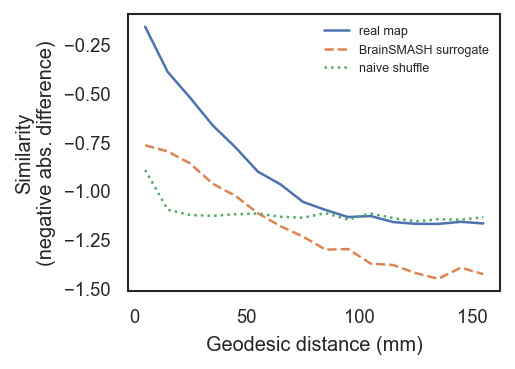

In [11]:
def distance_profile(values, D, edges):
    iu = np.triu_indices(len(values), k=1)
    d = D[iu]
    similarity = -np.abs(values[iu[0]] - values[iu[1]])
    keep = np.isfinite(d)
    d, similarity = d[keep], similarity[keep]
    centres, means = [], []
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = (d >= lo) & (d < hi)
        if m.sum():
            centres.append((lo + hi) / 2)
            means.append(similarity[m].mean())
    return np.array(centres), np.array(means)

edges = np.linspace(0, 160, 17)
shuffled = np.random.default_rng(0).permutation(myelin)

fig, ax = plt.subplots(figsize=(3.2, 2.4), dpi=150)
for values, label, style in [(myelin, 'real map', '-'),
                             (myelin_null_geo[0], 'BrainSMASH surrogate', '--'),
                             (shuffled, 'naive shuffle', ':')]:
    centres, means = distance_profile(values, D_geo, edges)
    ax.plot(centres, means, style, label=label, linewidth=1.2)
ax.set_xlabel('Geodesic distance (mm)')
ax.set_ylabel('Similarity\n(negative abs. difference)')
ax.legend(fontsize=6, frameon=False)
plt.show()

The real map and the surrogate rise and fall together: nearby parcels similar, distant parcels not.
The naive shuffle is flat past the first bin — it says the same thing at 20 mm as at 150 mm, having
destroyed exactly the structure that needs preserving. That is why shuffling parcels is not a valid
null for a brain map.

## Does the basis actually change the answer?

Everything above argued that the Euclidean basis is the wrong geometry. Here is what it costs.
Generate a second set of surrogates on the Euclidean basis and compare the two nulls against the
*same* observed correlation.

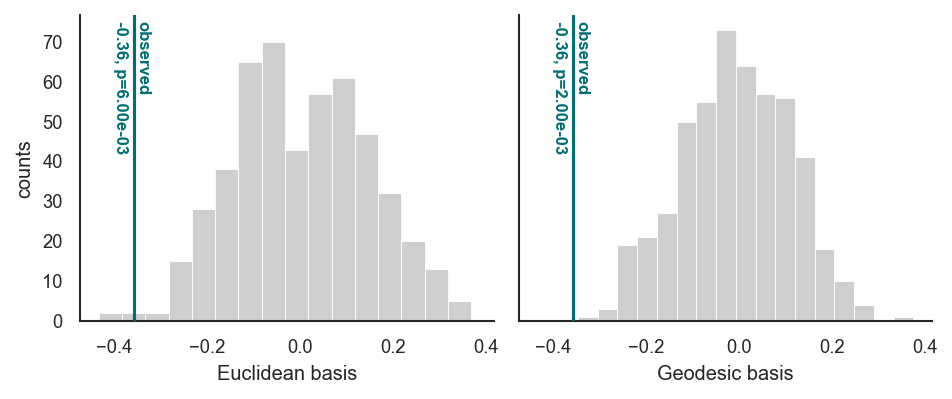

observed rho = -0.358
Euclidean : SD = 0.143, p = 0.006
geodesic  : SD = 0.117, p = 0.002


In [12]:
# For contrast: the old Euclidean single-block basis.
myelin_null_euc = generate_surrogates(myelin, n_regions=400, n_perms=n_perms,
                                      kind='euclidean', distance_matrix=D_euclid, hemi=hemi,
                                      per_hemisphere=False, seed=0)

observed = st.spearmanr(myelin, timescale)[0]
null_euc = np.array([st.spearmanr(s, timescale)[0] for s in myelin_null_euc])
null_geo = np.array([st.spearmanr(s, timescale)[0] for s in myelin_null_geo])

p_euc = get_null_p(observed, null_euc)
p_geo = get_null_p(observed, null_geo)

fig, axes = plt.subplots(1, 2, figsize=(6.4, 2.7), dpi=150, sharex=True, sharey=True)
null_plot(observed, null_euc, 'Euclidean basis', ax=axes[0], p_val=p_euc)
null_plot(observed, null_geo, 'Geodesic basis',  ax=axes[1], p_val=p_geo)
plt.tight_layout(); plt.show()

print(f'observed rho = {observed:.3f}')
print(f'Euclidean : SD = {null_euc.std():.3f}, p = {p_euc:.3f}')
print(f'geodesic  : SD = {null_geo.std():.3f}, p = {p_geo:.3f}')

Both panels compare the same observed `rho = -0.358` against a null centred on zero, and both call
it significant — but they do not agree on how significant. The geodesic null is the **narrower** of
the two here (SD 0.117 against 0.143), and returns `p = 0.002` where the Euclidean basis returns
`p = 0.006`: a threefold difference in the reported evidence, from the same map and the same
coefficient, decided entirely by which geometry the surrogates were built on.

Do not read a fixed direction into that. Which basis gives the smaller p-value depends on the map,
and the Euclidean null is not reliably narrower or wider — the point is that a choice of distance
metric you may not have thought about is setting your p-value. For a surface parcellation the
defensible choice is the one that matches how the cortex is actually connected, which is geodesic.
Whenever you have a surface parcellation, prefer `kind='geodesic'`.

Note also that `p = 0.002` is exactly `1/500` — the geodesic p-value has hit the resolution floor
of this null, which is the subject of the warning further down.

The whole test is also available as a single call — {func}`~snaplab_tools.nulls.corr_with_null`
recomputes the correlation under each surrogate and returns the observed value alongside the
BrainSMASH p-value:

In [13]:
# timescale is held fixed; the target (myelin) is the one that gets surrogated.
result = corr_with_null(timescale, myelin, myelin_null_geo, method='spearman')
print(f"rho = {result['r']:.3f},  BrainSMASH p = {result['p_smash']:.3f},  n = {result['n']} regions")

rho = -0.358,  BrainSMASH p = 0.002,  n = 400 regions


## What the parametric test would have claimed

Compare that p-value against the one you would have reported from a standard correlation test:

In [14]:
rho_parametric, p_parametric = st.spearmanr(myelin, timescale)
print(f'parametric p  = {p_parametric:.2e}')
print(f'BrainSMASH p  = {result["p_smash"]:.4f}')
print(f'ratio         = {result["p_smash"] / p_parametric:.0e} times larger')

parametric p  = 1.60e-13
BrainSMASH p  = 0.0020
ratio         = 1e+10 times larger


Orders of magnitude apart — from the same data and the same coefficient. The parametric p-value is
not a slightly optimistic version of the right answer; it is answering a different question, one
whose assumptions the data violate.

## Controlling for a covariate map

Often a third map is the real explanation — for example, a correlation with cortical thickness that is entirely
carried by the sensorimotor-association axis.
{func}`~snaplab_tools.nulls.corr_with_covar_null` residualizes both maps on the covariates *and*
applies the same residualization inside the null, so the comparison stays fair.

In [15]:
# A covariate that genuinely shares variance with both maps -- the situation where controlling
# for it changes the answer.
covariate = make_correlated_map(myelin, rho=0.6, seed=7)

partial = corr_with_covar_null(timescale, myelin, covariate.reshape(-1, 1),
                               myelin_null_geo, method='spearman')

print(f"raw rho     = {result['r']:+.3f}  (p = {result['p_smash']:.3f})")
print(f"partial rho = {partial['r']:+.3f}  (p = {partial['p_smash']:.3f})")

raw rho     = -0.358  (p = 0.002)
partial rho = -0.312  (p = 0.018)


Controlling for the covariate moves the correlation from -0.358 to -0.312 and the p-value from
0.002 to 0.018 — still significant, but an order of magnitude weaker. Whether that is the right
analysis depends entirely on whether the covariate is a confound or part of the effect, which is a
question about your hypothesis rather than about the statistics.

The key detail is that the residualization is applied *inside* the null as well as to the observed
data. Residualizing your real maps and then comparing against an unresidualized null would compare
two different quantities and inflate significance.

## Testing several maps at once

{func}`~snaplab_tools.nulls.correlate_family` correlates one map against a family of others,
reusing the machinery above and applying FDR correction across the family — which you need as soon
as you test more than one relationship.

In [16]:
df_targets = pd.DataFrame({
    'map A': make_correlated_map(myelin, rho=0.45, seed=11),
    'map B': make_correlated_map(myelin, rho=0.20, seed=12),
    'map C': make_correlated_map(myelin, rho=0.00, seed=13),
})

table = correlate_family(myelin, df_targets, n_perms=n_perms, method='spearman',
                         distance_matrix=D_geo, hemi=hemi)
table[['r', 'p_smash', 'n', 'fdr_sig']]

targets: 100%|██████████| 3/3 [01:09<00:00, 23.03s/it]


,r,p_smash,n,fdr_sig
map A,0.433353,0.006,400.0,True
map B,0.189448,0.264,400.0,False
map C,0.042178,0.798,400.0,False


The three maps were planted at 0.45, 0.20 and 0.00. Map A survives; map C correctly does not.

Map B is the interesting one: a **real** correlation of 0.20 that does not survive. Against a spatial null, an effect of 0.20 across 400
autocorrelated parcels is simply not distinguishable from smoothness. Worth remembering before
designing a study around a small predicted effect — and worth remembering when a paper reports one
with a parametric p-value.

## Computing null p-values yourself

{func}`~snaplab_tools.stats.get_null_p` turns any observed statistic plus any null vector into a
p-value. It knows nothing about brain maps, so it works equally well for permutation tests of
prediction accuracy or anything else.

`alternative='two-sided'` (the default) tests magnitude, which is almost always what you want for
a correlation — the hypothesis is rarely about the sign. `'auto'` picks whichever tail the observed
effect points in; it reports smaller p-values, and because the direction comes from the data it is
not a pre-registered one-tailed test.

In [17]:
print(f"two-sided (magnitude)  : {get_null_p(observed, null_geo):.4f}")
print(f"one-tailed ('auto')    : {get_null_p(observed, null_geo, alternative='auto'):.4f}")

two-sided (magnitude)  : 0.0020
one-tailed ('auto')    : 0.0000


:::{warning}
The one-tailed value above printed as `0.0000`, and that is the point: a p-value of exactly 0
means "smaller than this null can resolve", not "zero". With `n_perms` surrogates the smallest
non-zero value obtainable is `1/n_perms`. Report it as `p < 0.002`, never as `p = 0`.
:::

# 2) Null network models

Coming soon!

Surrogate *maps* are the right null for parcel-wise data. Testing a property of a **network** —
rich-club organisation, modularity, path length — needs a different kind of null: rewired graphs
that preserve degree sequence, weight distribution, or spatial embedding.

## See also

- [Plotting correlations](plotting_correlations.ipynb) — embedding a null inside a scatter plot
- {func}`~snaplab_tools.stats.steiger_test` — comparing two correlations that share a variable
- {func}`~snaplab_tools.stats.get_fdr_p` — the FDR correction `correlate_family` applies